-Graphics-
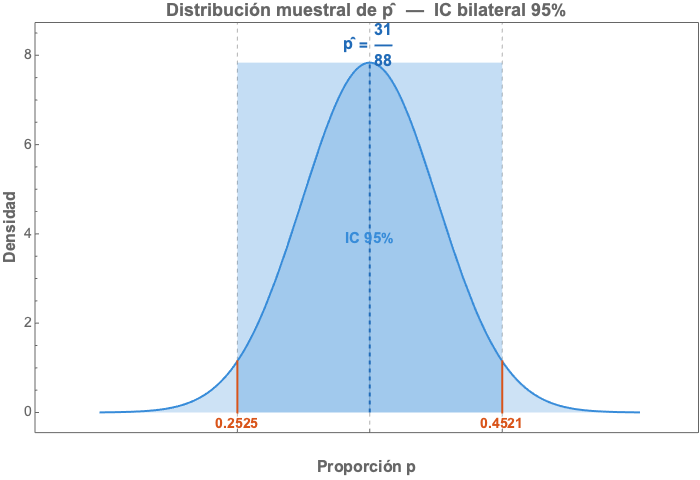

In [76]:
ClearAll["Global`*"]
(* Parámetros del problema *)
n = 88; x = 31;
phat = x/n;
se = Sqrt[phat (1 - phat) / n];
z = 1.96;
liInf = phat - z se;
liSup = phat + z se;

(* Distribución normal centrada en p-hat *)
dist = NormalDistribution[phat, se];

Plot[
  PDF[dist, p], {p, phat - 4 se, phat + 4 se},
  PlotTheme -> "Scientific",
  
  Filling -> {1 -> {Axis, Directive[Opacity[0.25], RGBColor[0.22, 0.55, 0.85]]}},
  FillingStyle -> Directive[Opacity[0.08], Gray],
  
  Epilog -> {
    (* Región del IC en azul *)
    {Opacity[0.3], RGBColor[0.22, 0.55, 0.85],
     Rectangle[{liInf, 0}, {liSup, PDF[dist, phat]}]},
    
    (* Línea p-hat *)
    {Thick, Dashed, RGBColor[0.13, 0.42, 0.72],
     Line[{{phat, 0}, {phat, PDF[dist, phat]}}]},
    
    (* Límites IC *)
    {Thick, RGBColor[0.85, 0.33, 0.1],
     Line[{{liInf, 0}, {liInf, PDF[dist, liInf]}}]},
    {Thick, RGBColor[0.85, 0.33, 0.1],
     Line[{{liSup, 0}, {liSup, PDF[dist, liSup]}}]},
    
    (* Etiquetas - tamaños aumentados *)
    Text[Style[Row[{"p̂ = ", NumberForm[phat, {4, 4}]}], 16, Bold, 
      RGBColor[0.13, 0.42, 0.72]], {phat, PDF[dist, phat] + 0.4}],
    
    Text[Style[NumberForm[liInf, {4, 4}], 14, Bold, RGBColor[0.85, 0.33, 0.1]],
      {liInf, -0.25}],
    Text[Style[NumberForm[liSup, {4, 4}], 14, Bold, RGBColor[0.85, 0.33, 0.1]],
      {liSup, -0.25}],
    
    Text[Style["IC 95%", 15, Bold, RGBColor[0.22, 0.55, 0.85]],
      {phat, PDF[dist, phat]/2}]
  },
  
  PlotRange -> {{0.1, 0.6}, {-0.45, PDF[dist, phat] + 0.9}},
  
  Frame -> True,
  FrameLabel -> {
    Style["Proporción p", 16, Bold],
    Style["Densidad", 16, Bold]
  },
  
  FrameTicks -> {
    {Automatic, None},
    {{{liInf, ""}, {phat, ""}, {liSup, ""}}, None}
  },
  
  PlotStyle -> {Thick, RGBColor[0.22, 0.55, 0.85]},
  
  GridLines -> {{liInf, phat, liSup}, None},
  GridLinesStyle -> Directive[Dashed, GrayLevel[0.7]],
  
  PlotLabel -> Style[
    "Distribución muestral de p̂  —  IC bilateral 95%", 18, Bold],
  
  LabelStyle -> {FontSize -> 14},
  ImageSize -> 700,
  BaseStyle -> {FontSize -> 14}
]